In [1]:
import xarray as xr
import scipy
import numpy as np
import pandas as pd
import copy
from datetime import datetime
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import pandas as pd
import numpy as np
from scipy.sparse import diags
import matplotlib.pyplot as plt
import os
import re
from typing import List, Optional
import numpy as np
import pandas as pd
from typing import Tuple
import torch
from sklearn.linear_model import LinearRegression
import proto_scales.data_prep.prepare_data as prep
import pickle

In [2]:
@torch.no_grad()
def forecast(model, y_ctx, u_ctx, pr_ctx, u_fut,n_samples = 1):
   
    device = y_ctx.device
    B, H, Du = u_fut.shape

    # DeepSSM mean forecast (IMPORTANT: mean, no observation noise)
    y_ssm, _, _,pr_ssm,_,_ = model.forecast(y_ctx, u_ctx, u_fut, steps=H, n_samples=n_samples,pr_ctx=pr_ctx)  # [B,H,Dy]
    # If your forecast adds obs noise, remove it for MSE evaluation.

    y_lin = model.ssm.ctrl_lin(u_fut.reshape(-1, Du)).reshape(B, H, -1)

    return y_ssm, y_lin, pr_ssm

In [3]:
def get_fastmip_gmt(filename):
    df = pd.read_csv(filename)
    # Expand yearly GMT projections to monthly by repeating each year's value 12 times
    gmt_cols = [c for c in df.columns if c != 'year']
    
    df_monthly = pd.DataFrame({
        'year':  np.repeat(df['year'].values, 12),
        'month': np.tile(np.arange(1, 13), len(df)),
        **{col: np.repeat(df[col].values, 12) for col in gmt_cols}
    })
    
    # u shape expected by the model: [n_scenarios, T, 1]
    # Each column of df is one GMT projection / calibration
    u_fastmip = df_monthly[gmt_cols].values.T[:, :, np.newaxis]  # [n_projections, T_monthly, 1]
    return u_fastmip,df_monthly,gmt_cols

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os
path = "/pdrive/projects/icigroup/projects/FastMIP/scenarios/"
scenarios = os.listdir('/pdrive/projects/icigroup/projects/FastMIP/scenarios/')
scenario_index = 0
SCENARIO = scenarios[scenario_index]


files = [path+scenario for scenario in scenarios]
print(files)

u_fastmip,df_monthly,gmt_cols = get_fastmip_gmt(files[scenario_index])

print(f"u_fastmip shape: {u_fastmip.shape}  (n_projections, T_monthly, 1)")

#df = pd.read_csv("/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP5---Medium-Low-Emissions_a_fair_GMT_data.csv")
#df = pd.read_csv("/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP3---High-Emissions_fair_GMT_data.csv")


# df.head()
# x = df['year'].values
# y = df['385'].values

# plt.plot(x,y)


['/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP1---Very-Low-Emissions_fair_GMT_data.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP5---Medium-Low-Emissions_a_fair_GMT_data_inc_variability.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP1---Very-Low-Emissions_fair_GMT_data_inc_variability.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Medium-Emissions_fair_GMT_data_inc_variability.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Low-Emissions_fair_GMT_data_inc_variability.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Low-Overshoot_a_fair_GMT_data.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Medium-Low-Emissions_fair_GMT_data.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Medium-Low-Emissions_fair_GMT_data_inc_variability.csv', '/pdrive/projects/icigroup/projects/FastMIP/scenarios/SSP2---Low-Overshoot_a_fair_GMT_data_inc_variability.csv', '/pdrive

In [5]:
from proto_scales.ssm_model.scales_ssm import StandardScaler

# from proto_scales.multi_esm_model.scales_cnp import DeepCnpSsmforESM,DeepSSMPatternConditioned
# scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_cnp_20260615_150246/"
# model_filename = scaler_path+"checkpoints/cnp_epoch1030.pt" 
# zdim = 64
# rnn_hidden=256
# use_linear_model = True
# emission_uses_u =True
# alpha_max = 0.002
# resevoir_dim = 4

from proto_scales.multi_esm_model.scales_cnp import DeepCnpSsmforESM,DeepSSMPatternConditioned
scaler_path ="/home/kainverena/PythonProjects/outputs_ssm_scales/scales_cnp_20260724_130848/"
model_filename = scaler_path+"checkpoints/cnp_epoch0620.pt" 
zdim = 64
rnn_hidden=256
use_linear_model = True
emission_uses_u =True
alpha_max = 0.002
resevoir_dim = 4



scaler_pickle_y_scaler_filename = scaler_path+"y_scaler.out"
scaler_pickle_u_scaler_filename = scaler_path+"u_scaler.out"
scaler_pickle_pr_scaler_filename = scaler_path+"pr_scaler.out"

y_scaler = StandardScaler.from_file(scaler_pickle_y_scaler_filename)
u_scaler = StandardScaler.from_file(scaler_pickle_u_scaler_filename)
pr_scaler = StandardScaler.from_file(scaler_pickle_pr_scaler_filename)

In [18]:
def create_all_model_test_dict(model_list, indicators, test_scenarios):
    model_data = {}
    for model in model_list:
        MODEL_PATH = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{model}'
        
        test_data_np = prep.fetch_and_massage_data(
        model_path=MODEL_PATH,
        indicators=INDICATORS,
        train_scenarios=TEST_SCENARIOS,
        monthly_flag=True,
        use_smoothing=False,
        train_pattern_scaling_name='ss585',
        pattern_scaling_residuals=False,
        ramp_down_corrected_ps=False,
        )
        model_data[model] = test_data_np

    return model_data

def prepare_data_for_inference(t_horizon,t_context,raw_data):
    test_data_np = np.array(raw_data)
    test_gmt = test_data_np[:,0,:]
    test_data_np = test_data_np[:,1:,:]
    regions = int(test_data_np.shape[1]/2)
    tas_test = test_data_np[:,:regions,:]
    tas_test = np.transpose(tas_test,(0, 2, 1))
    pr_test = test_data_np[:,-regions:,:]
    pr_test = np.transpose(pr_test,(0, 2, 1))
    y_past = tas_test[:,:t_context,:]
    pr_past =pr_test[:,:t_context,:]
    u_past = np.expand_dims(test_gmt[:,:t_context],axis=2)
    u_future = np.expand_dims(test_gmt[:,t_context:t_context+t_horizon],axis=2)
    return y_past, pr_past, u_past, u_future,tas_test,pr_test
    
    
models = ['MPI-ESM1-2-LR','ACCESS-ESM1-5','CanESM5','MIROC6','IPSL-CM6A-LR']
INDICATORS = ['tas','pr']
TEST_SCENARIOS = ['ssp245']
#TRAIN_SCENARIOS = [ 'ssp585','1pctco2']#,'ssp534-over','flat10cdrincspinoff','ssp126','flat10zecincspinoff', 'flat10cdrincspinoff']#,'abrupt4xco2','ssp119','ssp460','ssp370']

model_data = create_all_model_test_dict(models,INDICATORS,TEST_SCENARIOS)


fetch_and_massage_data: retained 30/30 scenarios: ['mpi-esm1-2-lr_ssp245-r30i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r20i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r11i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r15i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r27i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r17i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r6i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r13i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r10i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r21i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r8i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r3i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r16i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r2i1p1f1_tas_ipcc-regions_latweight.csv', 'mpi-esm1-2-lr_ssp245-r22i1p1f1_tas_ipcc-re

In [19]:
MODEL = models[0]
test_data_np = model_data[MODEL]

Tc_test = 600
H =2100

y_past, pr_past, u_past, u_future,tas_test,pr_test = prepare_data_for_inference(H,Tc_test,test_data_np)



In [20]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB']

In [21]:
device = "cpu"
Dy = 58#tas_test.shape[-1]
Du = 1#test_gmt.shape[-1]

# model = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
#                                  emission_uses_u=emission_uses_u).to(device)
model_ssm = DeepSSMPatternConditioned(y_dim=Dy, u_dim=Du, z_dim=zdim,rnn_hidden=rnn_hidden,use_linear_model=use_linear_model,
                                 emission_uses_u=emission_uses_u,reservoir_dim=resevoir_dim,alpha_max=alpha_max).to(device)


model = DeepCnpSsmforESM(ssm_model=model_ssm,r_dim = 128, z_cnp_dim=32)  
model.load_state_dict(torch.load(model_filename, map_location=torch.device(device)))
model.eval()

DeepCnpSsmforESM(
  (ssm): DeepSSMPatternConditioned(
    (gru): GRU(59, 256, batch_first=True)
    (q_head): Linear(in_features=256, out_features=128, bias=True)
    (trans): MLP(
      (net): Sequential(
        (0): Linear(in_features=65, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
      )
    )
    (u_gru): GRU(1, 64, batch_first=True)
    (omega_lin): Linear(in_features=64, out_features=232, bias=False)
    (emit): MLP(
      (net): Sequential(
        (0): Linear(in_features=360, out_features=128, bias=True)
        (1): SiLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): SiLU()
        (4): Linear(in_features=128, out_features=116, bias=True)
      )
    )
    (emit_pr): MLP(
      (net): Sequential(
        (0): Linear(in_features=360, out_features=230, bias=True)
        (1): SiLU()
      

In [48]:
def project_for_ESM(esm_name,esm_member_index,gmt_future, n_ensemble):
    rng = np.random.default_rng(seed=42)
    #idx = rng.choice(len(U_future_access), size=30, replace=False)
    idx = range(n_ensemble)
    

    MODEL = models[0]
    test_data_np = model_data[MODEL]

    Tc_test = 600
    H =2100

    y_past, pr_past, u_past, u_future,_,_ = prepare_data_for_inference(H,Tc_test,test_data_np)
    u_future = gmt_future[idx]
    B = u_future.shape[0]
    
    # Use only the first ESM member for context, repeated B times
    y_past_n  = np.repeat(y_scaler.transform(y_past[[esm_member_index]]),   B, axis=0)
    pr_past_n = np.repeat(pr_scaler.transform(pr_past[[esm_member_index]]), B, axis=0)
    u_past_n  = np.repeat(u_scaler.transform(u_past[[esm_member_index]]),   B, axis=0)
    u_future_n = u_scaler.transform(u_future)
    
    y_past_n   = torch.tensor(y_past_n,   device=device, dtype=torch.float32)
    u_past_n   = torch.tensor(u_past_n,   device=device, dtype=torch.float32)
    u_future_n = torch.tensor(u_future_n, device=device, dtype=torch.float32)
    pr_past_n  = torch.tensor(pr_past_n,  device=device, dtype=torch.float32)
    
    with torch.no_grad():
        y_ssm, y_lin, pr_ssm = forecast(model, y_past_n, u_past_n, pr_past_n, u_future_n, n_samples=1)
    y_pred     = y_scaler.inverse_transform(y_ssm.cpu().numpy())
    pr_pred    = pr_scaler.inverse_transform(pr_ssm.cpu().numpy())
    y_pred_lin = y_scaler.inverse_transform(y_lin.cpu().numpy())
    
    y_pred_mean = np.mean(y_pred,axis=0)
    y_pred_lin_mean = np.mean(y_pred_lin,axis=0)
    pr_pred_mean = np.mean(pr_pred,axis=0)
    
    y_yearly_mean     = [np.mean(y_pred_mean[i-12:i])     for i in np.arange(12,len(y_pred_mean),12)]
    y_yearly_mean_lin = [np.mean(y_pred_lin_mean[i-12:i]) for i in np.arange(12,len(y_pred_lin_mean),12)]
    pr_yearly_mean = [np.mean(pr_pred_mean[i-12:i])     for i in np.arange(12,len(pr_pred_mean),12)]
    output_data ={}
    output_data["tas"] = y_pred
    output_data["pr"] = pr_pred
    output_data["pattern_scaling_tas"] = y_pred_lin
    output_data["tas_yearly"] = y_yearly_mean
    output_data["pr_yearly"] = pr_yearly_mean
    output_data["tas_lin_yearly"] = y_yearly_mean_lin
    output_data["calibration_indices"] = idx
    return output_data

In [23]:
def center_histogram(histo: np.ndarray, bin_edges: np.ndarray):
    bins_centre = []
    for k in range(1, len(bin_edges)):
        bins_centre.append((bin_edges[k] + bin_edges[k - 1]) / 2.)
    return histo, bins_centre

def get_hist_vec(data, bins=10, rangeH=None, density=True):
    histo, bin_edge = np.histogram(data, bins=bins, range=rangeH, density=density)
    return center_histogram(histo, bin_edge)

def get_hist_vec_cum(data, bins=10, rangeH=None, density=True, cumulative=True):
    histo, bin_edge, _ = plt.hist(data, bins=bins, range=rangeH, density=density, cumulative=cumulative)
    plt.clf()
    return center_histogram(histo, bin_edge)

In [24]:
U_future_access = u_fastmip

(30, 2100, 58)
..  (30, 2100, 58) (2100,)


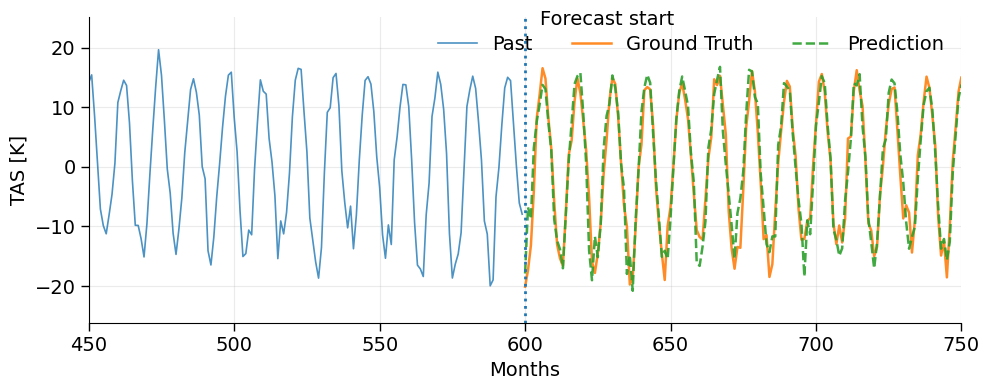

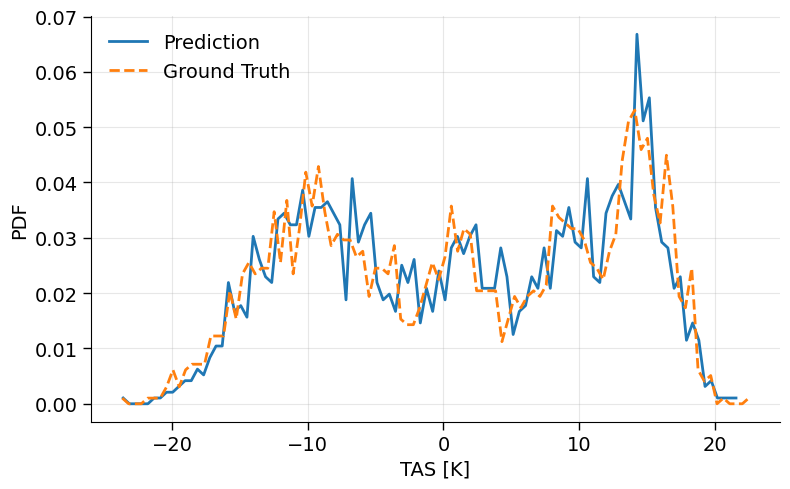

In [25]:






# y_past = tas_test[:,-(Tc_test+H):-H,:]
# u_past = np.expand_dims(test_gmt[:,-(Tc_test+H):-H],axis=2)
# u_future = np.expand_dims(test_gmt[:,-H:],axis=2)


y_past_n = y_scaler.transform(y_past)
u_past_n = u_scaler.transform(u_past)
u_future_n = u_scaler.transform(u_future)
pr_past_n = pr_scaler.transform(pr_past)


y_past_n = torch.tensor(y_past_n,device=device,dtype=torch.float32)
u_past_n = torch.tensor(u_past_n,device=device,dtype=torch.float32)
u_future_n = torch.tensor(u_future_n,device=device,dtype=torch.float32)
pr_past_n = torch.tensor(pr_past_n,device=device,dtype=torch.float32)
        
with torch.no_grad():
    y_ssm,y_lin,pr_ssm = forecast(model, y_past_n, u_past_n, pr_past_n, u_future_n,n_samples = 1)
y_pred = y_scaler.inverse_transform(y_ssm.cpu().numpy())
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu().numpy())
print(y_pred.shape)

pred_data = {
    "tas":y_pred,
    "pr":pr_pred
}

region = region_names.index("EEU")
sample = 0

y_1, x_1 = get_hist_vec(tas_test[sample,Tc_test:Tc_test+H,region], bins=100)
y_2,x_2 = get_hist_vec(y_pred[sample,:,region], bins=100)



#plt.xlim([2300,2500])

# plt.figure()
# plt.plot(np.arange(Tc_test,Tc_test+H),y_pred[sample,:,region])
# plt.plot(np.arange(Tc_test,Tc_test+H),tas_test[sample,-H:,region])
# plt.plot(y_past[sample,:,region])


# t_future = np.arange(Tc_test, Tc_test + H)
# t_past = np.arange(Tc_test - y_past.shape[1], Tc_test)


t_future = np.arange(Tc_test, Tc_test + H)
t_past = np.arange(0, Tc_test)
print(".. ",y_pred.shape,t_future.shape)



plt.figure(figsize=(10, 4))

plt.xlim([450,750])
# Past context
plt.plot(
    t_past,
    y_past[sample, :, region],
    label="Past",
    linewidth=1.2,
    alpha=0.8
)

# Ground truth future
plt.plot(
    t_future[:H],
    tas_test[sample,Tc_test:Tc_test+H, region],
    label="Ground Truth",
    linewidth=1.8,
    alpha=0.9
)

# Prediction
plt.plot(
    t_future,
    y_pred[sample, :, region],
    label="Prediction",
    linewidth=1.8,
    alpha=0.9,
    linestyle="--"
)
plt.tick_params(axis="both", labelsize=14, length=6, width=1)

# Vertical line separating past and forecast horizon
plt.axvline(Tc_test, linestyle=":", linewidth=2)
plt.text(Tc_test + 5, plt.ylim()[1] * 0.95, "Forecast start", fontsize=14)

# Labels and styling
plt.xlabel("Months", fontsize=14)
plt.ylabel("TAS [K]", fontsize=14)
#plt.title("Past Context and Forecast Comparison", fontsize=14)

plt.legend(frameon=False, ncol=3,fontsize=14)
plt.grid(alpha=0.25)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()



plt.figure(figsize=(8, 5))

# Estimate bin width (assuming uniform bins)
bin_width_1 = np.diff(x_1).mean()
bin_width_2 = np.diff(x_2).mean()

# Plot bars
# plt.bar(x_1, y_1, width=bin_width_1, alpha=0.5, label="Ground Truth", align="center")
# plt.bar(x_2, y_2, width=bin_width_2, alpha=0.5, label="Prediction", align="center")

plt.plot(x_2, y_2, label="Prediction", linewidth=2)
plt.plot(x_1, y_1, label="Ground Truth", linewidth=2, linestyle="--")
plt.tick_params(axis="both", labelsize=14, length=6, width=1)

# Labels and title
plt.xlabel("TAS [K]", fontsize=14)
plt.ylabel("PDF", fontsize=14)
#plt.title("Distribution of TAS: Prediction vs Ground Truth", fontsize=14)

# Styling
plt.grid(alpha=0.3)
plt.legend(frameon=False,fontsize=14)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [26]:
def get_variability_from_data(n_first_indices,y_gt):
    monthly_data=[]
    for i in range(12):
        monthly_data.append([])
        for j in np.arange(i,n_first_indices,12):
            monthly_data[i].append(y_gt[j])
        
    variability = np.zeros_like(y_gt)
    
    for i in range(12):
        for j in np.arange(i,len(variability),12):
            variability[j]=np.std(np.array(monthly_data[i]))
    return variability

-2.3538316966955732 2.532519108675527
(30, 2700, 1)


/scratch/slurm/2824177/ipykernel_137679/437092649.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)
/scratch/slurm/2824177/ipykernel_137679/437092649.py:100: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(pr_pred-pr_gt)


<Figure size 640x480 with 0 Axes>

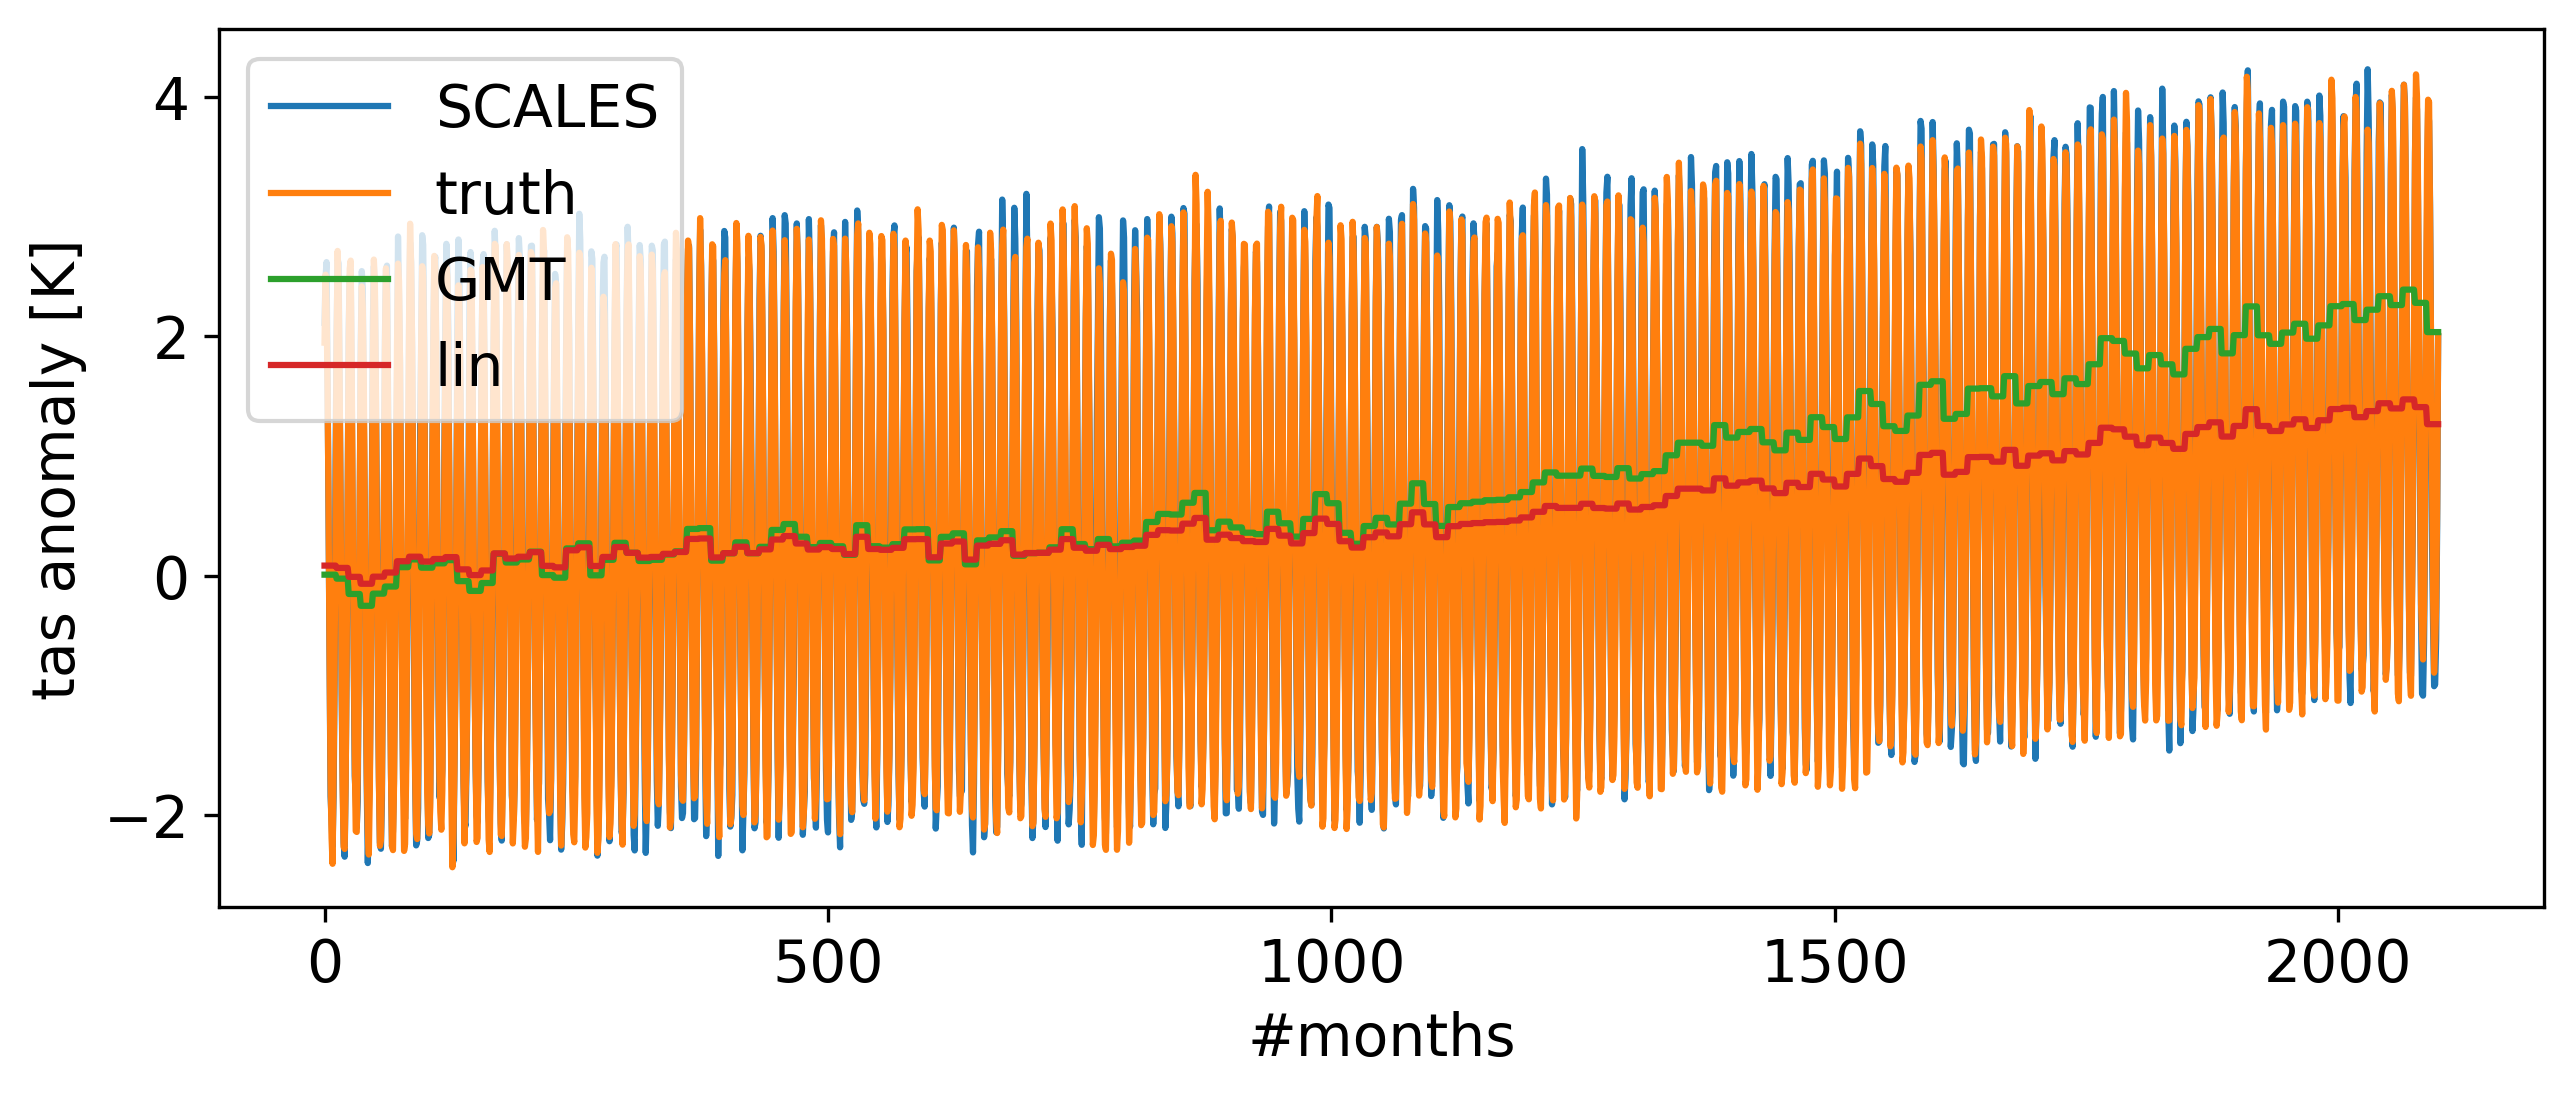

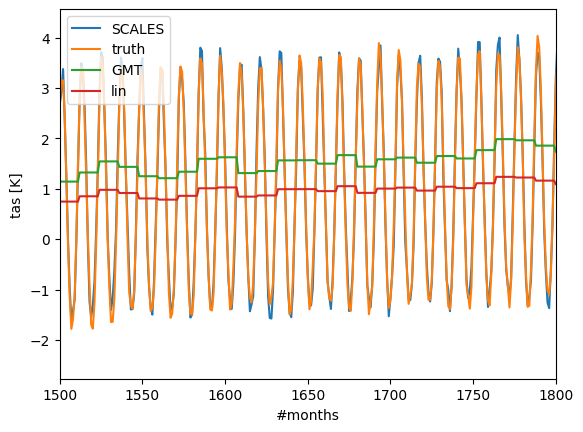

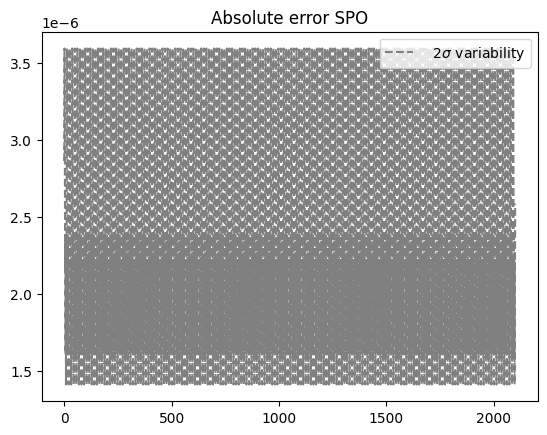

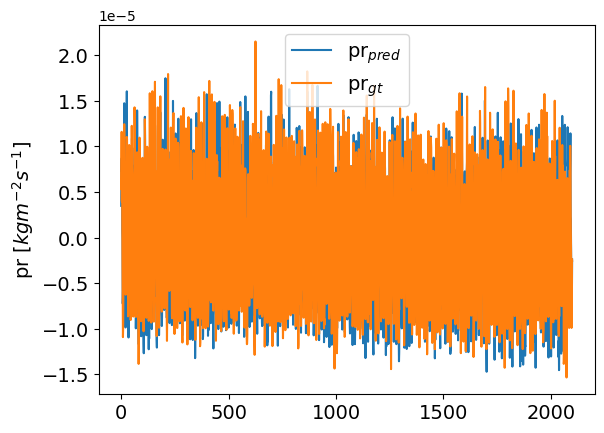

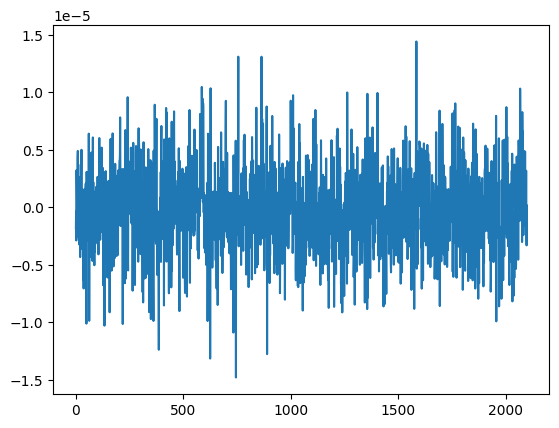

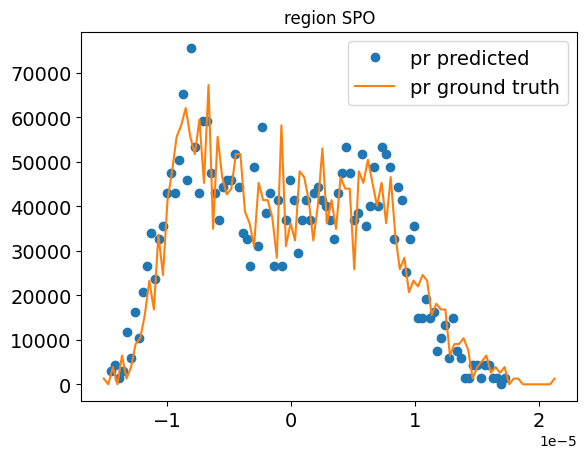

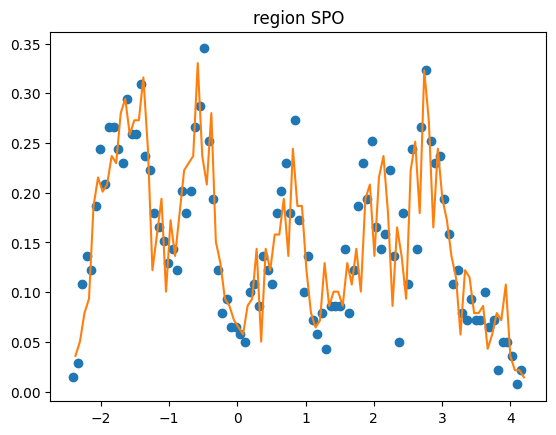

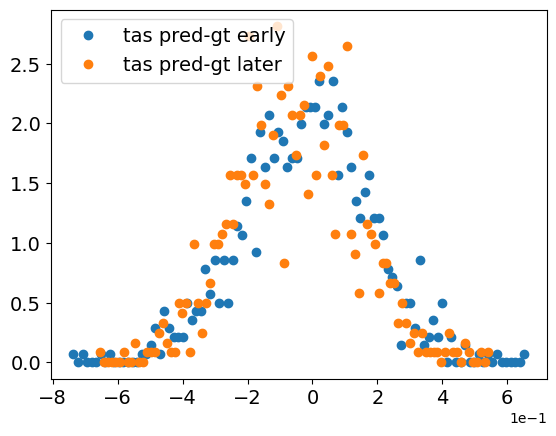

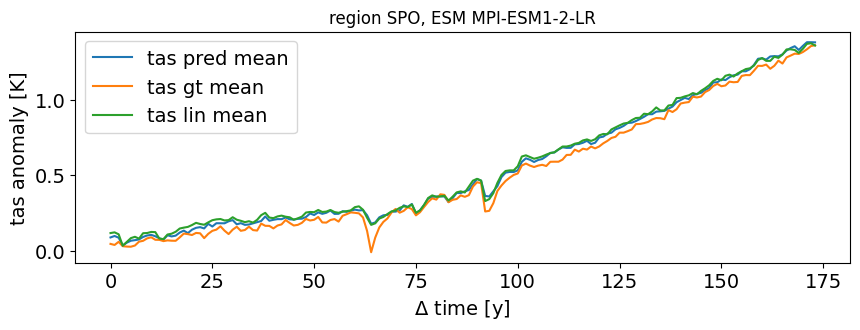

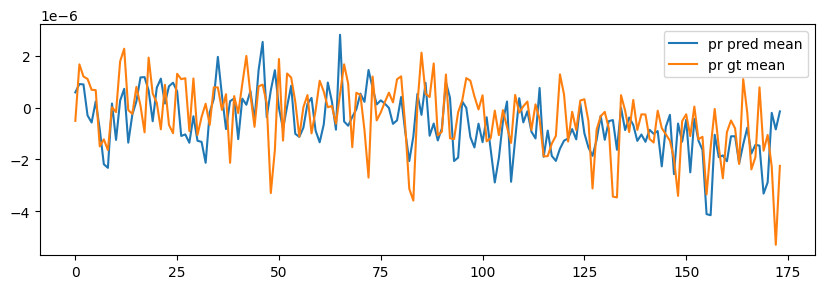

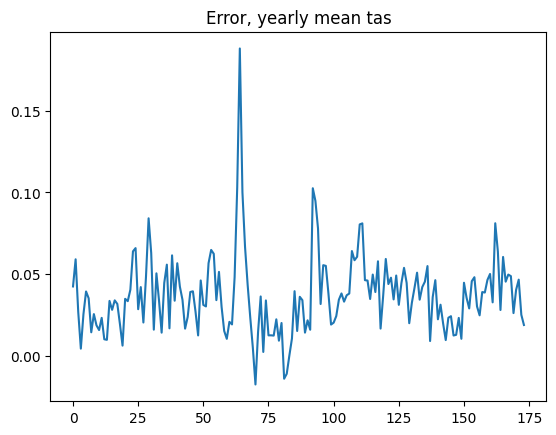

In [34]:
region_names = ['ARO', 'ARP', 'ARS', 'BOB', 'CAF', 'CAR', 'CAU',
       'CNA', 'EAN', 'EAO', 'EAS', 'EAU', 'ECA', 'EEU', 'EIO', 'ENA', 'EPO',
       'ESAF', 'ESB', 'GIC', 'MDG', 'MED', 'NAO', 'NAU', 'NCA', 'NEAF', 'NEN',
       'NES', 'NEU', 'NPO', 'NSA', 'NWN', 'NWS', 'NZ', 'RAR', 'RFE', 'SAH',
       'SAM', 'SAO', 'SAS', 'SAU', 'SCA', 'SEA', 'SEAF', 'SES', 'SIO', 'SOO',
       'SPO', 'SSA', 'SWS', 'TIB', 'WAF', 'WAN', 'WCA', 'WCE', 'WNA', 'WSAF',
       'WSB']
sample = 0 #17 bad for pr; 15, 35, 27 for ssp534-over

test_gmt = np.concat((u_past,u_future),axis=1)

region = region_names.index("SPO")
region = region
y_pred = y_scaler.inverse_transform(y_ssm.cpu())[sample,:,region]
y_pred_lin = y_scaler.inverse_transform(y_lin.cpu())[sample,:,region]
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu())[sample,:,region]

y_gt = tas_test[sample,Tc_test:Tc_test+H,region]#y_t_n[0,-H:,region]
pr_gt = pr_test[sample,Tc_test:Tc_test+H,region]

y_gt_mean = np.mean(tas_test[:,Tc_test:Tc_test+H,region],axis=0)#y_t_n[0,-H:,region]
pr_gt_mean = np.mean(pr_test[:,Tc_test:Tc_test+H,region],axis=0)
y_pred_mean = np.mean(y_scaler.inverse_transform(y_ssm.cpu().numpy())[:,:,region],axis =0)
y_pred_lin_mean = np.mean(y_scaler.inverse_transform(y_lin.cpu().numpy())[:,:,region],axis =0)
y_gt_std = np.std(tas_test[:,Tc_test:Tc_test+H,region],axis=0)#y_t_n[0,-H:,region]
y_pred_std = np.std(y_scaler.inverse_transform(y_ssm.cpu().numpy())[:,:,region],axis =0)

variability = get_variability_from_data(400,pr_gt)


y_1, x_1 = get_hist_vec((pr_gt), bins=100)
y_2,x_2 = get_hist_vec((pr_pred), bins=100)
y_3, x_3 = get_hist_vec((y_gt), bins=100)
y_4,x_4 = get_hist_vec((y_pred), bins=100)
y_5, x_5 = get_hist_vec((y_gt[:1000]-y_pred.numpy()[:1000]), bins=100)
y_6,x_6 = get_hist_vec((y_gt[-1000:]-y_pred.numpy()[-1000:]), bins=100)
y_cdf_1, x_cdf_1 = get_hist_vec_cum(np.abs(y_pred-y_gt), bins=100)

pi_period = 300
y_for_normalisation = y_gt[0:pi_period]-y_pred_lin[0:pi_period].cpu().numpy()
y_norm_max = np.percentile(y_for_normalisation,95)
y_norm_min = np.percentile(y_for_normalisation,5)
print(y_norm_min,y_norm_max)
print(test_gmt.shape)

y_yearly_mean = [np.mean(y_pred_mean[i-12:i]) for i in np.arange(12,len(y_pred),12)]
y_yearly_mean_2 = [np.mean(y_pred[i-12:i].numpy()) for i in np.arange(14,len(y_pred),12)]
y_yearly_gt = [np.mean(y_gt_mean[i-12:i]) for i in np.arange(12,len(y_gt),12)]
y_yearly_lin = [np.mean(y_pred_lin_mean[i-12:i]) for i in np.arange(12,len(y_pred_lin),12)]
y_yearly_gt_std = [np.mean(y_gt_std[i-12:i]) for i in np.arange(12,len(y_pred_lin),12)]
y_yearly_std = [np.mean(y_pred_std[i-12:i]) for i in np.arange(12,len(y_pred),12)]
y_yearly_mean = np.array(y_yearly_mean)
y_yearly_gt = np.array(y_yearly_gt)


pr_yearly_mean = [np.mean(pr_pred[i-12:i].numpy()) for i in np.arange(12,len(pr_pred),12)]
pr_yearly_gt = [np.mean(pr_gt[i-12:i]) for i in np.arange(12,len(pr_gt),12)]

#plt.title(f"{TEST_SCENARIOS}, region {region_names[region]}, single sample")
plt.figure(figsize=(10, 3.8), dpi=300)
plt.ylabel("tas anomaly [K]",fontsize=14)
plt.xlabel("#months",fontsize=14)
plt.plot(y_pred, label="SCALES")
plt.plot(y_gt,label="truth")
plt.plot(test_gmt[sample,Tc_test:Tc_test+H],label="GMT")
plt.plot(y_pred_lin,label="lin")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.figure()
plt.ylabel("tas [K]")
plt.xlabel("#months")
plt.xlim([4800,5000])
plt.xlim([1500,1800])
plt.plot(y_pred,label="SCALES")
plt.plot(y_gt,label="truth")
plt.plot(test_gmt[sample,-H:],label="GMT")
plt.plot(y_pred_lin,label="lin")
plt.legend()
# plt.figure()
# #plt.xlim([1500,2000])
# plt.title("Normalised error")
# plt.plot(((y_pred-y_gt)-y_norm_min)*2./(y_norm_max-y_norm_min)-1.)
plt.figure()
#plt.ylim([-2,2])
plt.title(f"Absolute error {region_names[region]}")
#plt.xlim([0,2000])
#plt.plot(y_pred-y_gt, label = "y$_{pred}$ - y$_{gt}$")
plt.plot(variability,color="grey",ls="--",label = "  $2\sigma$ variability")
#plt.plot(variability*(-2),color = "grey",ls="--")
plt.legend()
plt.figure()
#plt.xlim([2100,2300])
plt.ylabel("pr [$kg m^{-2} s^{-1}$]",fontsize=14)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.plot(pr_pred,label="pr$_{pred}$")
plt.plot(pr_gt,label = "pr$_{gt}$")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
plt.figure()
plt.plot(pr_pred-pr_gt)
plt.figure()
plt.title(f"region {region_names[region]}")
plt.plot(x_2,y_2, "o",label = "pr predicted")
plt.plot(x_1,y_1, label = "pr ground truth")
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(fontsize=14)
plt.figure()
plt.title(f"region {region_names[region]}")
plt.plot(x_3,y_3,"o",label = "tas pred")
plt.plot(x_4,y_4, label = "tas gt")
plt.figure()
plt.plot(x_5,y_5,"o",label = "tas pred-gt early")
plt.plot(x_6,y_6,"o",label = "tas pred-gt later")
plt.legend()
# plt.plot(x_6,y_6, label = "tas gt - later")
plt.tick_params(axis='both', labelsize=14)
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
plt.legend(fontsize=14)
plt.figure(figsize=(10,3))
plt.xlabel("$\Delta$ time [y]",fontsize=14)
plt.ylabel("tas anomaly [K]",fontsize=14)
plt.title(f"region {region_names[region]}, ESM {MODEL}")
plt.plot(y_yearly_mean,label="tas pred mean")
#plt.plot(y_yearly_mean+y_yearly_std,"--",color="black")
#plt.plot(y_yearly_mean-y_yearly_std,"--",color="black")
plt.plot(y_yearly_gt,label = "tas gt mean")
#plt.plot(y_yearly_gt+y_yearly_gt_std,"--",color="grey")
#plt.plot(y_yearly_gt-y_yearly_gt_std,"--",color="grey")
plt.plot(y_yearly_lin,label = "tas lin mean")
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=14)
# plt.xlabel("$\Delta$ time [y]")
# plt.ylabel("tas anomaly [K]")
# plt.plot(y_yearly_mean,label="tas pred mean")
# plt.plot(y_yearly_mean+y_yearly_std,"--",color="black")
# plt.plot(y_yearly_mean-y_yearly_std,"--",color="black")
# plt.plot(y_yearly_gt,label = "tas gt mean")
# plt.plot(y_yearly_gt+y_yearly_gt_std,"--",color="grey")
# plt.plot(y_yearly_gt-y_yearly_gt_std,"--",color="grey")
# plt.plot(y_yearly_lin,label = "tas lin mean")
# plt.legend()
plt.figure(figsize=(10,3))
plt.plot(pr_yearly_mean,label="pr pred mean")
#plt.plot(y_yearly_mean_2,label="predicted mean 2")
plt.plot(pr_yearly_gt,label = "pr gt mean")
plt.legend()
plt.figure()
plt.title("Error, yearly mean tas")
plt.plot(y_yearly_mean - y_yearly_gt)

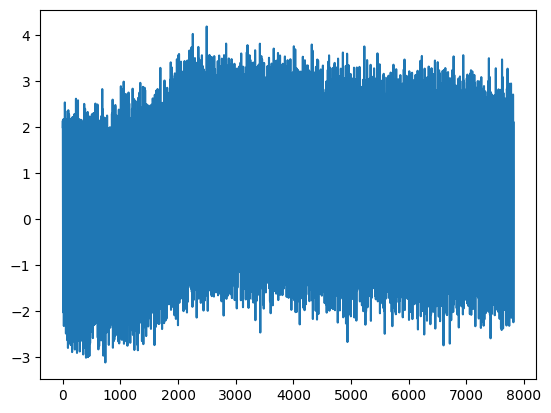

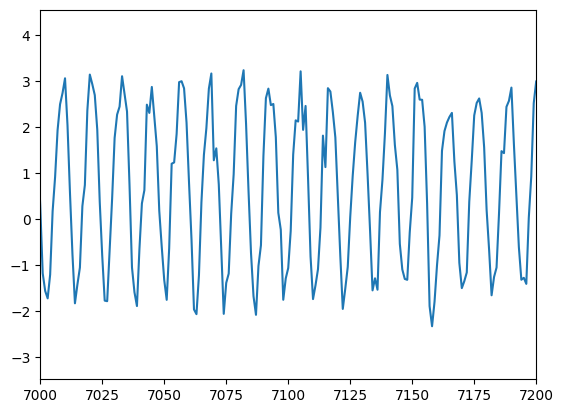

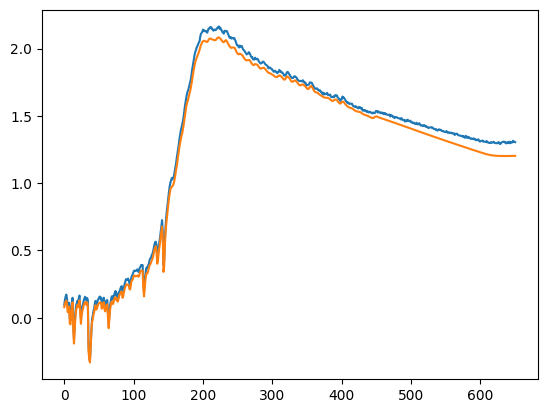

In [49]:

data = project_for_ESM(esm_name=models[0],esm_member_index=0,gmt_future=u_fastmip, n_ensemble=100)
#print(data.keys())
y_pred = data["tas"]
y_yearly_mean = data["tas_yearly"]
y_yearly_mean_lin = data["tas_lin_yearly"]

sample = 0
region = region_names.index("MDG")

plt.plot(y_pred[sample,:,region])


fig = plt.figure()
plt.xlim([7000,7200])
plt.plot(y_pred[sample,:,region])


fig = plt.figure()
plt.plot(y_yearly_mean)
plt.plot(y_yearly_mean_lin)



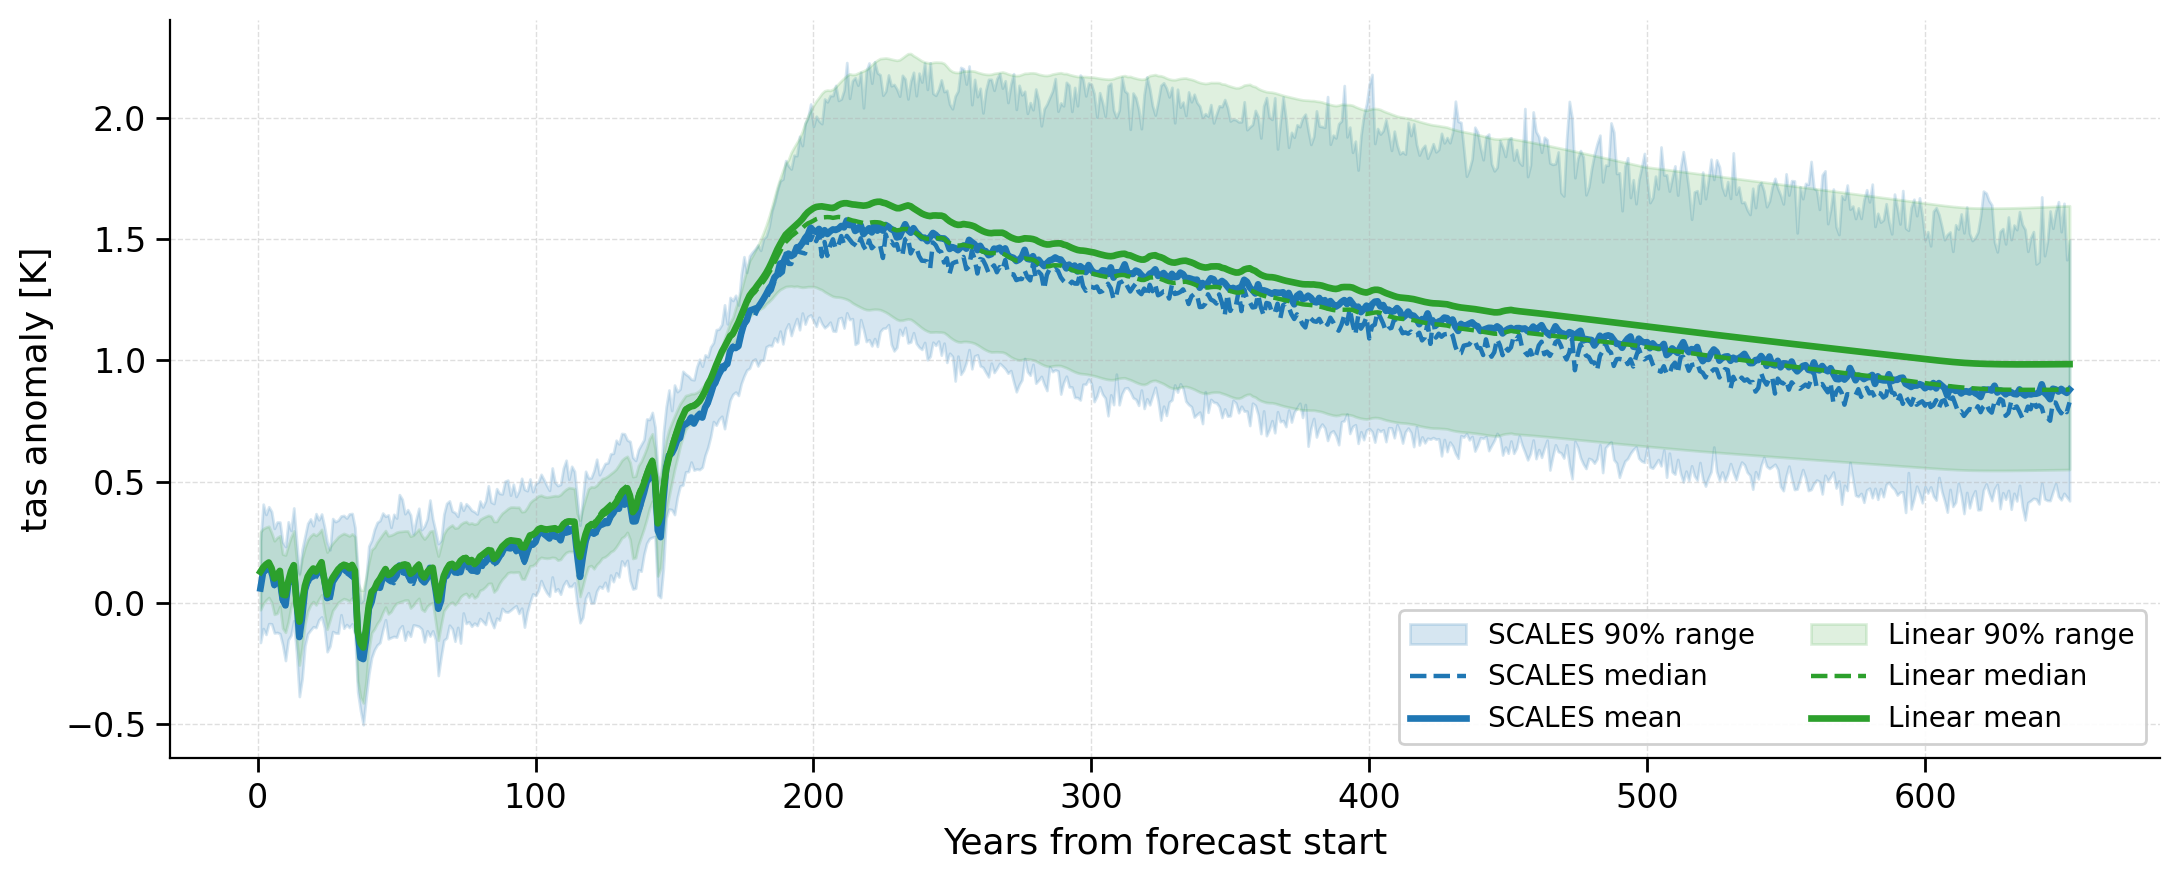

In [50]:
# ── Per-projection yearly means [n_proj, n_years] ───────────────────────────
years_idx = np.arange(12, y_pred.shape[1] + 1, 12)

y_pred_lin = data["pattern_scaling_tas"]
y_yearly_per_proj = np.array([
    [np.mean(y_pred[i, k-12:k, region]) for k in years_idx]
    for i in range(y_pred.shape[0])
])
lin_yearly_per_proj = np.array([
    [np.mean(y_pred_lin[i, k-12:k, region]) for k in years_idx]
    for i in range(y_pred_lin.shape[0])
])

# ── Statistics across projections ────────────────────────────────────────────
y_mean    = y_yearly_per_proj.mean(axis=0)
y_median  = np.median(y_yearly_per_proj, axis=0)
y_p5      = np.percentile(y_yearly_per_proj,  5, axis=0)
y_p95     = np.percentile(y_yearly_per_proj, 95, axis=0)

lin_mean   = lin_yearly_per_proj.mean(axis=0)
lin_median = np.median(lin_yearly_per_proj, axis=0)
lin_p5     = np.percentile(lin_yearly_per_proj,  5, axis=0)
lin_p95    = np.percentile(lin_yearly_per_proj, 95, axis=0)

x     = np.arange(1, len(y_mean) + 1)
#x_gt  = np.arange(1, len(y_yearly_mean_gt) + 1)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4.5), dpi=200)

# SCALES — 90 % band, median, mean
ax.fill_between(x, y_p5, y_p95,
                color="#1f77b4", alpha=0.18, label="SCALES 90% range")
ax.plot(x, y_median,
        color="#1f77b4", linewidth=1.6, linestyle="--", label="SCALES median")
ax.plot(x, y_mean,
        color="#1f77b4", linewidth=2.4, label="SCALES mean")

# Linear — 90 % band, median, mean
ax.fill_between(x, lin_p5, lin_p95,
                color="#2ca02c", alpha=0.15, label="Linear 90% range")
ax.plot(x, lin_median,
        color="#2ca02c", linewidth=1.6, linestyle="--", label="Linear median")
ax.plot(x, lin_mean,
        color="#2ca02c", linewidth=2.4, label="Linear mean")

# Ground truth
#n_gt = min(len(x_gt), len(x))
# ax.plot(x_gt[:n_gt], y_yearly_mean_gt[:n_gt],
#         color="#d62728", linewidth=2.4, label=f"ESM ({MODEL})")

# Styling
ax.set_xlabel("Years from forecast start", fontsize=13)
ax.set_ylabel("tas anomaly [K]", fontsize=13)
ax.tick_params(axis="both", labelsize=12, length=5, width=1)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
ax.legend(fontsize=10, frameon=True, framealpha=0.92, edgecolor="0.8",
          ncol=2, loc="best")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
#plt.savefig("/home/kainverena/PythonProjects/scales_plots/soo_ssp126_30Apr26_yearly_reservoir_no_hidden.pdf")

In [58]:
import xarray as xr
import cftime
import os

ds_list = []

for esm_name in models:
    data = project_for_ESM(esm_name=esm_name, esm_member_index=0,
                           gmt_future=u_fastmip, n_ensemble=100)
    y_pred   = data["tas"]
    pr_pred  = data["pr"]
    idx      = data["calibration_indices"]

    # ── Time coordinate (cftime handles years beyond 2262) ────────────────────
    H_pred     = y_pred.shape[1]
    time_df    = df_monthly.iloc[:H_pred].reset_index(drop=True)
    time_index = [
        cftime.DatetimeGregorian(int(r["year"]), int(r["month"]), 1)
        for _, r in time_df.iterrows()
    ]

    proj_names = np.array(gmt_cols)[idx]   # [n_realisations]

    ds_esm = xr.Dataset(
        data_vars={
            "tas": (
                ["realisation", "time", "region"],
                y_pred,
                {"long_name": "Near-surface air temperature anomaly", "units": "K"},
            ),
            "pr": (
                ["realisation", "time", "region"],
                pr_pred,
                {"long_name": "Precipitation flux", "units": "kg m-2 s-1"},
            ),
        },
        coords={
            "realisation": ("realisation", proj_names),
            "time":        ("time",        time_index),
            "region":      ("region",      region_names),
            "esm":         esm_name,
        },
        attrs={"scenario": SCENARIO,
               "description": "SCALES monthly emulator output — FastMIP GMT projections"},
    )
    ds_list.append(ds_esm)
    print(f"  {esm_name}: {y_pred.shape}")

ds = xr.concat(ds_list, dim="esm")
print(ds)

#── Save ──────────────────────────────────────────────────────────────────────
out_dir = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/fastMIP"
os.makedirs(out_dir, exist_ok=True)
out_nc  = f"{out_dir}/{SCENARIO.replace('.csv','')}_tas_pr_monthly_scales.nc"
ds.to_netcdf(out_nc)
print(f"Saved -> {out_nc}")

  MPI-ESM1-2-LR: (100, 7824, 58)
  ACCESS-ESM1-5: (100, 7824, 58)
  CanESM5: (100, 7824, 58)
  MIROC6: (100, 7824, 58)
  IPSL-CM6A-LR: (100, 7824, 58)
<xarray.Dataset> Size: 2GB
Dimensions:      (esm: 5, realisation: 100, time: 7824, region: 58)
Coordinates:
  * esm          (esm) <U13 260B 'MPI-ESM1-2-LR' ... 'IPSL-CM6A-LR'
  * realisation  (realisation) <U7 3kB '385' '1926' '2551' ... '188069' '190367'
  * time         (time) object 63kB 1850-01-01 00:00:00 ... 2501-12-01 00:00:00
  * region       (region) <U4 928B 'ARO' 'ARP' 'ARS' ... 'WNA' 'WSAF' 'WSB'
Data variables:
    tas          (esm, realisation, time, region) float32 908MB -9.334 ... -8...
    pr           (esm, realisation, time, region) float32 908MB -1.552e-06 .....
Attributes:
    scenario:     SSP1---Very-Low-Emissions_fair_GMT_data.csv
    description:  SCALES monthly emulator output — FastMIP GMT projections
Saved -> /pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/fastMIP/SSP1---Very-Low-Emissions_fair_GMT_dat

/scratch/slurm/2824177/ipykernel_137679/3273047992.py:3: FutureWarning: Usage of 'use_cftime' as a kwarg is deprecated. Please pass a 'CFDatetimeCoder' instance initialized with 'use_cftime' to the 'decode_times' kwarg instead.
Example usage:
    time_coder = xr.coders.CFDatetimeCoder(use_cftime=True)
    ds = xr.open_dataset(decode_times=time_coder)

  ds_check = xr.open_dataset(out_nc, use_cftime=True)


<xarray.Dataset> Size: 2GB
Dimensions:      (esm: 5, realisation: 100, time: 7824, region: 58)
Coordinates:
  * esm          (esm) <U13 260B 'MPI-ESM1-2-LR' ... 'IPSL-CM6A-LR'
  * realisation  (realisation) <U6 2kB '385' '1926' '2551' ... '188069' '190367'
  * time         (time) object 63kB 1850-01-01 00:00:00 ... 2501-12-01 00:00:00
  * region       (region) <U4 928B 'ARO' 'ARP' 'ARS' ... 'WNA' 'WSAF' 'WSB'
Data variables:
    tas          (esm, realisation, time, region) float32 908MB ...
    pr           (esm, realisation, time, region) float32 908MB ...
Attributes:
    scenario:     SSP1---Very-Low-Emissions_fair_GMT_data.csv
    description:  SCALES monthly emulator output — FastMIP GMT projections


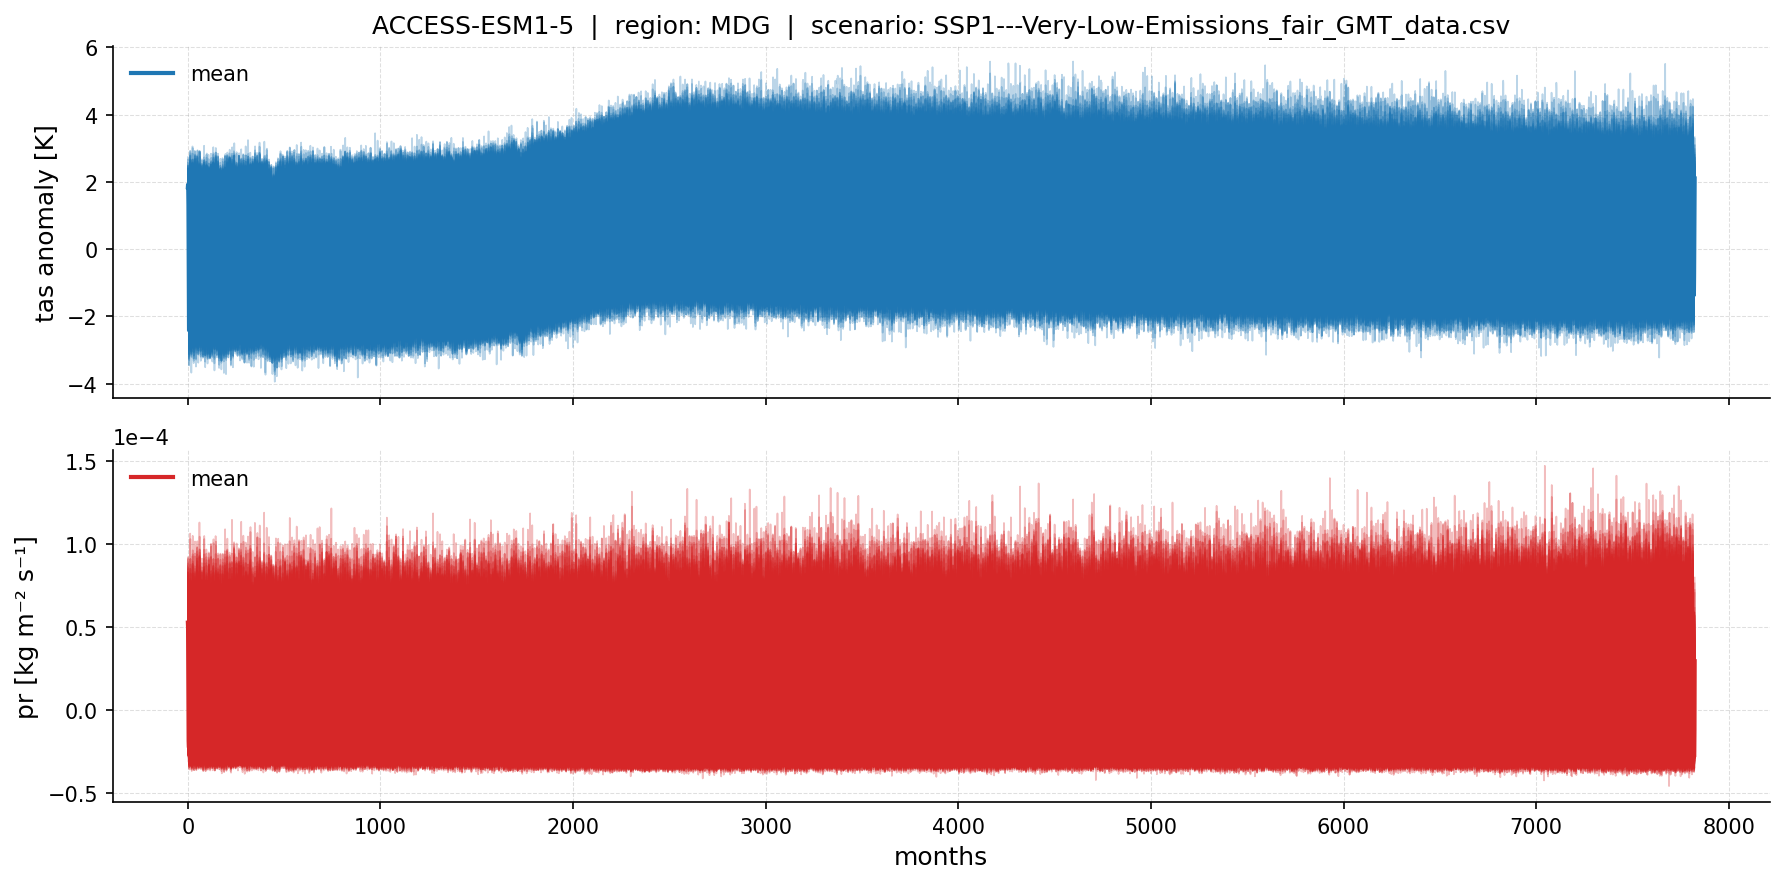

In [59]:
import xarray as xr

ds_check = xr.open_dataset(out_nc, use_cftime=True)
print(ds_check)

# ── Select ESM and region to inspect ─────────────────────────────────────────
esm_sel    = "ACCESS-ESM1-5"
region_sel = "MDG"

tas_sel = ds_check["tas"].sel(esm=esm_sel, region=region_sel)   # [realisation, time]
pr_sel  = ds_check["pr"].sel(esm=esm_sel,  region=region_sel)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=150, sharex=True)

for real in tas_sel.realisation.values:
    axes[0].plot(tas_sel.sel(realisation=real).values, alpha=0.3, linewidth=0.8, color="#1f77b4")
axes[0].plot(tas_sel.mean("realisation").values, color="#1f77b4", linewidth=2.0, label="mean")
axes[0].set_ylabel("tas anomaly [K]", fontsize=12)
axes[0].set_title(f"{esm_sel}  |  region: {region_sel}  |  scenario: {ds_check.attrs['scenario']}", fontsize=12)
axes[0].legend(fontsize=10, frameon=False)
axes[0].grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

for real in pr_sel.realisation.values:
    axes[1].plot(pr_sel.sel(realisation=real).values, alpha=0.3, linewidth=0.8, color="#d62728")
axes[1].plot(pr_sel.mean("realisation").values, color="#d62728", linewidth=2.0, label="mean")
axes[1].set_ylabel("pr [kg m⁻² s⁻¹]", fontsize=12)
axes[1].ticklabel_format(style="sci", axis="y", scilimits=(0, 0))
axes[1].set_xlabel("months", fontsize=12)
axes[1].legend(fontsize=10, frameon=False)
axes[1].grid(True, linestyle="--", linewidth=0.5, alpha=0.4)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

ds_check.close()

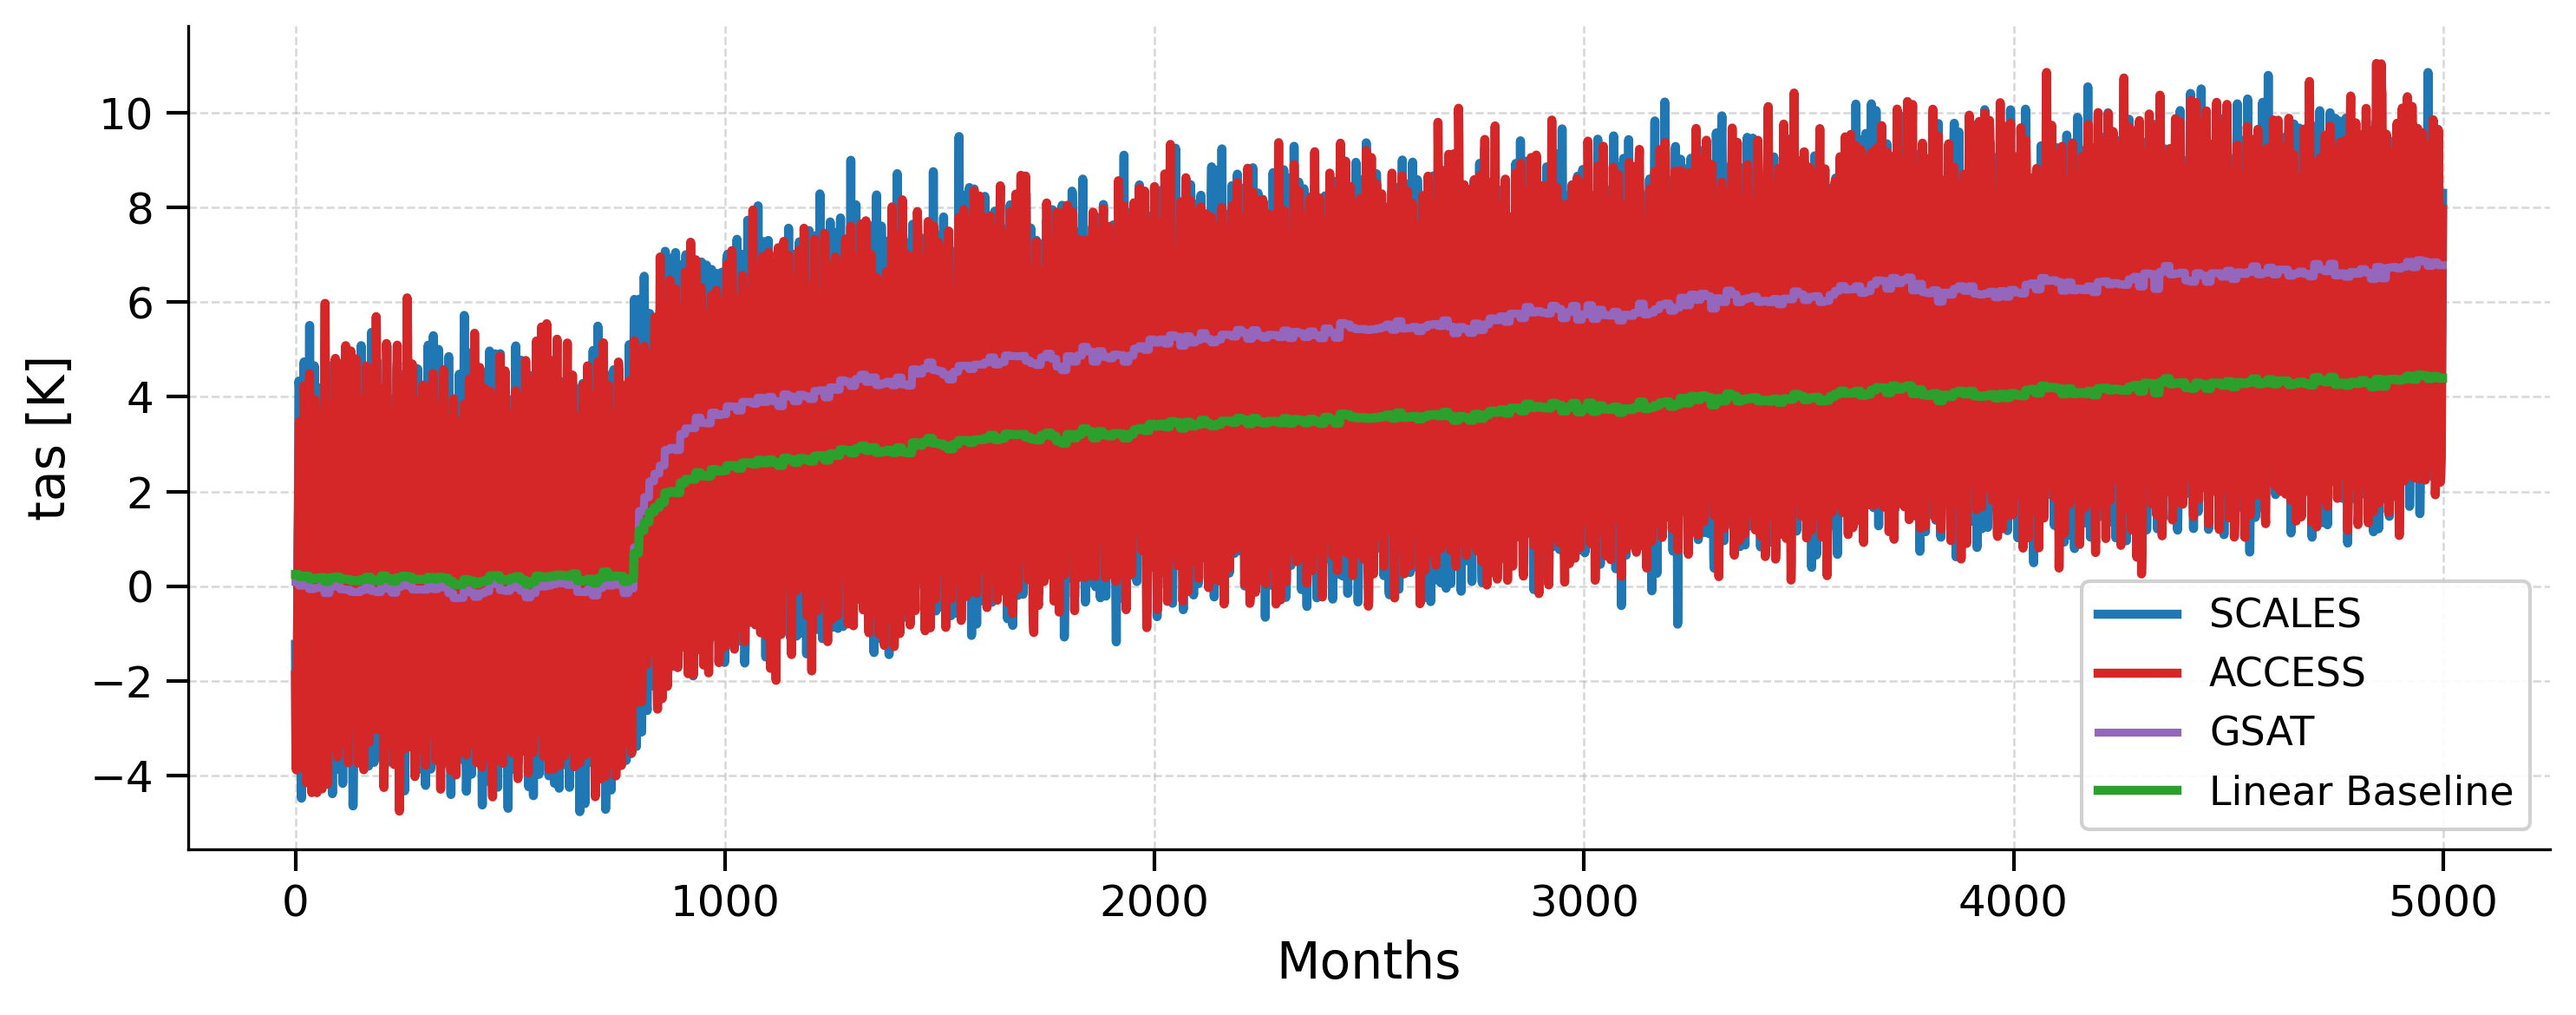

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4), dpi=300)

# Professional scientific color palette
plt.plot(
    y_pred,
    label="SCALES",
    linewidth=2.5,
    color="#1f77b4"   # deep blue
)

plt.plot(
    y_gt,
    label="ACCESS",
    linewidth=2.5,
    color="#d62728"   # muted red
)

plt.plot(
    test_gmt[sample, -H:],
    label="GSAT",
    linewidth=2.2,
    color="#9467bd"   # professional purple
)

plt.plot(
    y_pred_lin,
    label="Linear Baseline",
    linewidth=2.5,
    color="#2ca02c"   # muted green
)
#plt.xlim([4800,5000])
# Axis labels
plt.xlabel("Months", fontsize=14)
plt.ylabel("tas [K]", fontsize=14)

# Tick styling
plt.tick_params(
    axis="both",
    labelsize=12,
    length=6,
    width=1
)

# Subtle publication-style grid
plt.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.5
)

# Clean legend
plt.legend(
    fontsize=11,
    frameon=True,
    fancybox=True,
    framealpha=0.9,
    edgecolor="0.8",
    loc="best"
)

# Remove unnecessary spines for cleaner appearance
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Improve spacing
plt.tight_layout()
#plt.savefig("/home/kainverena/PythonProjects/scales_plots/sau_abrupt4c02_30Apr26.pdf")
plt.show()

In [14]:
Generation of ensemble data

(30, 3012, 58) (30, 3012)
(30, 2400, 1)


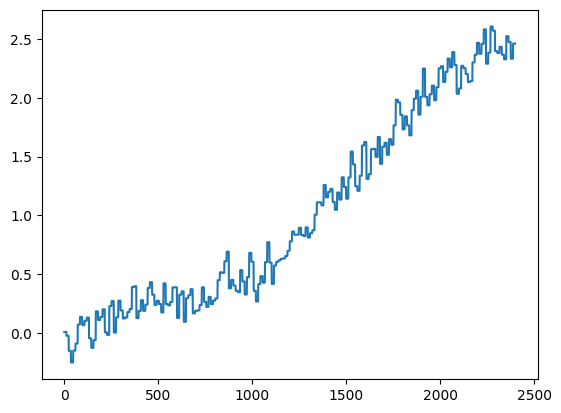

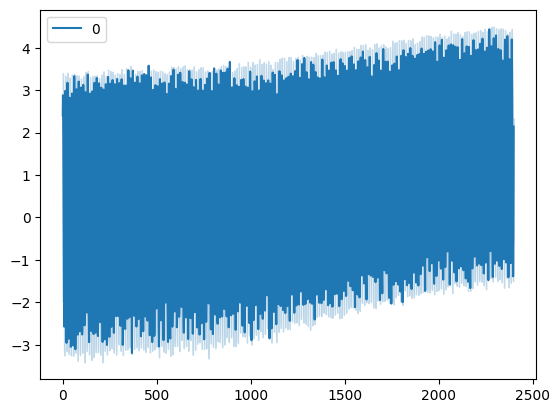

In [11]:
tas_test = test_data_np[:,:regions,:]
tas_test = np.transpose(tas_test,(0, 2, 1))
pr_test = test_data_np[:,-regions:,:]
pr_test = np.transpose(pr_test,(0, 2, 1))
print(tas_test.shape,test_gmt.shape)


Tc_test = 600
H = 2400

#y_past = tas_test[:,-(Tc_test+H):-H,:]
y_past = tas_test[:,:Tc_test,:]
pr_past = pr_test[:,:Tc_test,:]
#u_past = np.expand_dims(test_gmt[:,-(Tc_test+H):-H],axis=2)
u_past = np.expand_dims(test_gmt[:,:Tc_test],axis=2)
#u_future = np.expand_dims(test_gmt[:,-H:],axis=2)
u_future = np.expand_dims(test_gmt[:,Tc_test:(Tc_test+H)],axis=2)

plt.plot(u_future[0,:,0])

y_past_n = y_scaler.transform(y_past)
u_past_n = u_scaler.transform(u_past)
pr_past_n = pr_scaler.transform(pr_past)
u_future_n = u_scaler.transform(u_future)
print(u_future.shape)

y_past_n = torch.tensor(y_past_n,device=device,dtype=torch.float32)
pr_past_n = torch.tensor(pr_past_n,device=device,dtype=torch.float32)
u_past_n = torch.tensor(u_past_n,device=device,dtype=torch.float32)
u_future_n = torch.tensor(u_future_n,device=device,dtype=torch.float32)

# n_samples = 40

# y_pred_ensemble = []
# pr_pred_ensemble = []
# for i in range(n_samples):
        
with torch.no_grad():
   y_ssm,y_lin,pr_ssm = forecast(model, y_past_n, u_past_n, pr_past_n, u_future_n,n_samples = 1)
y_pred = y_scaler.inverse_transform(y_ssm.cpu().numpy())
pr_pred = pr_scaler.inverse_transform(pr_ssm.cpu().numpy())
y_pred_lin = y_scaler.inverse_transform(y_lin.cpu().numpy())
#y_pred_ensemble.append(y_pred)
#pr_pred_ensemble.append(pr_pred)
# y_pred_ensemble = np.array(y_pred_ensemble) #dim = n_samples,H,n_regions
# pr_pred_ensemble = np.array(pr_pred_ensemble)
pred_data = {
    "tas":y_pred,
    "pr":pr_pred,
    "tas_lin":y_pred_lin,
    "gsat":u_future,
    "tas_gt":tas_test[:,Tc_test:(Tc_test+H),:],
    "pr_gt":pr_test[:,Tc_test:(Tc_test+H),:]
}



# print(y_pred.shape)
# region = 1
# plt.figure()
# plt.xlim([0,300])
# #plt.xlim([2300,2500])
# plt.plot(np.arange(Tc_test,Tc_test+H),y_pred[15,:,region])
# plt.plot(np.arange(Tc_test,Tc_test+H),tas_test[15,Tc_test:Tc_test+H,region])
# plt.plot(y_past[15,:,region])


# import pickle
# pickle_filename = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/MPI-ESM1-2-LR/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl"
# pickle.dump(pred_data, open(pickle_filename, "wb"))

# import pickle
# pickle_filename = "/pdrive/projects/icigroup/SCALES-MESH/SCALES/emulator/MPI-ESM1-2-LR/ssp245_pr_tas_monthly_cnp_2400m_29Jun26.pkl"
# pred_data = pickle.load( open(pickle_filename, "rb") ) 



region = region_names.index("SOO")
sigma = np.std(pred_data["tas"][:,:,region],axis = 0)
mean =  np.mean(pred_data["tas"][:,:,region],axis = 0)

#pr_gt = pr_true[0,-H:,region]



plt.figure()
#plt.xlim([2600,2800])
#plt.plot(pred_data["pr"][39,:,region]+sigma,ls="--",color="grey")
#plt.plot(pred_data["pr"][39,:,region]-sigma,ls="--",color="grey")
#plt.plot(pred_data["tas"][39,:,region],color="black")
# plt.plot(pred_data["tas"][15,:,region],label="15")
# #plt.plot(tas_test[15,-H:,region],label="gt")
# plt.plot(pred_data["tas"][8,:,region],label="8")
# plt.plot(pred_data["tas"][12,:,region],label="12")
# plt.plot(pred_data["tas"][25,:,region],label="25")
# plt.plot(pred_data["tas"][30,:,region],label="30")
plt.plot(pred_data["tas"][0,:,region],label="0")
#plt.plot(pr_gt)
plt.fill_between(
    np.arange(0,len(pred_data["tas"][0,:,region]),1),
    mean-2*sigma,
    mean+2*sigma,
    color="tab:blue",
    alpha=0.25,
    #label="10–90% interval",
)
plt.legend()


In [52]:
#Check reading in ESM data
from proto_scales.multi_esm_model.scales_cnp import build_task_dict


models = ['CanESM5','ACCESS-ESM1-5','MPI-ESM1-2-LR','MIROC6']
weights = [1.,1.,1.,1.]
INDICATORS = ['tas','pr']
TRAIN_SCENARIOS = [ 'ssp534-over','ssp585','ssp370','ssp460','1pctco2','abrupt-4xco2','flat10zecincspinoff','flat10cdrincspinoff','ssp126']#,'1pctco2','ssp460','ssp534-over','abrupt-4xco2','flat10zecincspinoff','flat10cdrincspinoff','ssp126','ssp370']
  
esm_data = {}

for i,model in enumerate(models):
    task_data = {}
    model_path = f'/projects/icigroup/CMIP6/cmip6-ng-inc-oceans/{model}'

    u,tas,pr=prep.prepare_ds_data(
        model_path = model_path,
        train_scenarios=TRAIN_SCENARIOS,
        indicators=INDICATORS,
        sample_length=1800,
        n_skip=450,
        )
    task_data['y'] = tas
    task_data['pr'] = pr
    task_data['u'] = u
    task_data['weight'] = weights[i]
    esm_data[model] = task_data

Dy = tas.shape[-1]
Du = u.shape[-1]

tasks,scalers = build_task_dict(esm_data=esm_data,context_len=600,horizon=1200)

Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble
Info: Exact ensemble match not found. Using 'canesm5_picontrol-r1i1p2f1_tas_ipcc-regions_latweight.csv' with different ensemble


/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline

Info: Exact ensemble match not found. Using 'access-esm1-5_picontrol-r1i1p1f1_tas_ipcc-regions_latweight.csv' with different ensemble


/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:343: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_experiment = pd.read_csv(experiment_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(baseline_scenario_path, parse_dates=["time"])
/home/kainverena/PythonProjects/SCALES-test/proto_scales/data_prep/prepare_data.py:349: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_baseline = pd.read_csv(base

In [53]:
print(len(tasks['MPI-ESM1-2-LR']['support']))
print(len(tasks['ACCESS-ESM1-5']['support']))
print(len(tasks['CanESM5']['support']))
print(len(tasks['MIROC6']['support']))

203
700
392
234
